# Designing an Eco-friendly Intelligent Agent
Sammy the Spartan is an eco-friendly intelligent agent powered by carrots. 

In our upcoming assignments we'll guide  Sammy in his quests to collect medals in a maze.  Sammy can only move North, South, West or East.  He is unable to move diagonally.  
Sammy's carrot consumption is determined by his moves' directions.  For example, Sammy will consume more carrots moving backwards (East) than forward (West).  Sammy will also consume more carrots moving North than South. The exact number of carrots consumed for each direction is specified in the _cost_ dictionary in the Problem class defined in the [spartanquest](./spartanquest.ipynb) notebook.

The various positions in the maze are represented as a tuple of x and y coordinates. The top left position is (0, 0). The x coordinate increases as we move right in the grid and the y coordinate increases as we move down in the grid - as shown below.
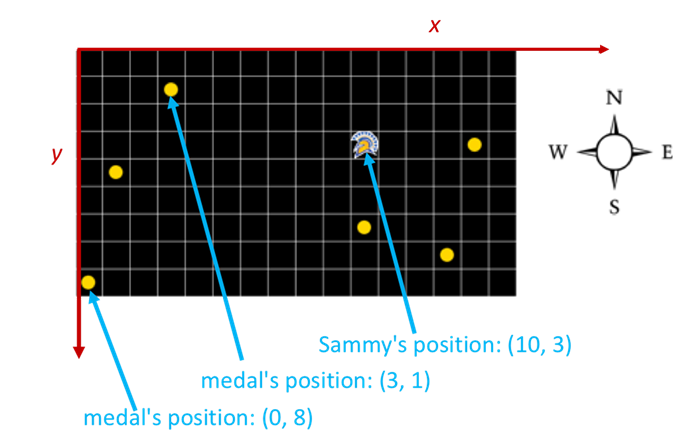

# Homework 1:  Uninformed Search
Your task this week is to help Sammy the Spartan on his quest by implementing some uninformed search algorithms.

The quest search problem has been formulated for you in the [spartanquest](./spartanquest.ipynb) notebook.
The data structures you need to use are defined for you in the [data_structures](./data_structures.ipynb) notebook.

In this notebook (uninformed_search), you'll implement two search algorithms.  This is the only notebook you need to submit when you complete your assignment.

Let's first import all we need before we get started.  Make sure you run the code cell below everytime you start working on this notebook.



In [ ]:
%run spartanquest.ipynb
from data_structures import *

## Depth First Search


The depth first graph search algorithm has been implemented for you in the dfs function below.  
Make sure you run the code cell to define the function.



In [ ]:
def dfs(problem):
    """
    Depth first graph search algorithm - implemented for you
    :param problem (a Problem object) representing the quest
            see Problem class definition in spartanquest.ipynb)
    :return: list of actions representing the solution to the quest
                or None if there is no solution
    """
    closed = set()  # keep track of our explored states
    fringe = Stack() # for dfs, the fringe is a stack
    state = problem.start_state()
    root = Node(state, None, None)
    fringe.push(root)
    while not fringe.is_empty():
        node = fringe.pop()
        if problem.is_goal(node.state):
            return node.solution()  # we found a solution
        if node.state not in closed:  # we are implementing graph search
            closed.add(node.state)
            for child_state, action, action_cost in problem.expand(node.state):
                child_cost = action_cost + node.cumulative_cost
                child_node = Node(child_state, node, action, child_cost)
                fringe.push(child_node)
    return None  # Failure -  no solution was found

Now let's see how how the depth first graph search algorithm solves the quest defined in [SJSU.txt](./SJSU.txt) by running the code cell below.  
Note that in the quest text file, S represents Sammy's start position, M represents a medal and W indicates the presence of a wall. 


In [ ]:
gospartans("SJSU.txt", "dfs")

As you can see in the visualization above, this is not only inefficient but it is also exasperating! 
Your task now is to help Sammy the Spartan find a more efficient solution by implementing the two search algorithms below.

## Breadth First Search
Implement the breadth first graph search algorithm by filling in your code in the function bfs below.  
Use the Node class and one of the data structures defined in the [data_structures](./data_structures.ipynb) notebook to implement the fringe.    
Make sure you run the code cell after you fill in or modify your code.

In [ ]:
def bfs(problem):
    """
    Breadth first graph search algorithm
    :param problem (a Problem object) representing the quest
            see Problem class definition in spartanquest.ipynb)
    :return: list of actions representing the solution to the quest
            or None if there is no solution
    """
    # Enter your  code here and remove the pass statement below
    closed = set()  # keep track of our explored states
    fringe = Queue() # for bfs, the fringe is a queue
    state = problem.start_state()
    root = Node(state, None, None)
    fringe.push(root)
    while not fringe.is_empty():
        node = fringe.pop()
        if problem.is_goal(node.state):
            return node.solution()  # we found a solution
        if node.state not in closed:  # we are implementing graph search
            closed.add(node.state)
            for child_state, action, action_cost in problem.expand(node.state):
                child_cost = action_cost + node.cumulative_cost
                child_node = Node(child_state, node, action, child_cost)
                fringe.push(child_node)
    return None  # Failure -  no solution was found


Now let's see how how the breadth first graph search algorithm solves the quest defined in SJSU.txt by running the code cell below:

In [ ]:
gospartans("SJSU.txt", "bfs")

For your convenience, here are the expected results for bfs on the quest described in sjsu.txt:  
Path length: 46  
Carrots consumed: 484  
Number of nodes expanded: 502 <-- 479 is ok too  
Processing time: 0.0027(sec) <-- this may be different for you  

## Uniform Cost Search
Implement the uniform cost graph search algorithm by filling in your code in the function ucs below.  
Use the Node class and one of the data structures defined in the [data_structures](./data_structures.ipynb) notebook.  
Make sure you run the code cell after you fill in or modify your code.

In [ ]:
def ucs(problem):
    """
    Uniform cost first graph search algorithm
    :param
    problem (a Problem object) representing the quest
            see Problem class definition in spartanquest.ipynby)
    :return: list of actions representing the solution to the quest
    """
    # Enter your code here and remove the pass statement below
    closed = set()  # keep track of our explored states
    fringe = PriorityQueue() # for bfs, the fringe is a priority queue
    state = problem.start_state()
    root = Node(state, None, None)
    fringe.push(root, 0)
    while not fringe.is_empty():
        node = fringe.pop()
        if problem.is_goal(node.state):
            return node.solution()  # we found a solution
        if node.state not in closed:  # we are implementing graph search
            closed.add(node.state)
            for child_state, action, action_cost in problem.expand(node.state):
                child_cost = action_cost + node.cumulative_cost
                child_node = Node(child_state, node, action, child_cost)
                fringe.push(child_node, child_cost)
    return None  # Failure -  no solution was found

Now let's see how how the uniform cost graph search algorithm solves the quest defined in SJSU.txt by running the code cell below:

In [ ]:
gospartans("SJSU.txt", "ucs")

For your convenience, here are the expected results for ucs on the quest described in sjsu.txt:  
Path length: 57  
Carrots consumed: 468  
Number of nodes expanded: 576  
Processing time: 0.0042(sec) <-- this may be different for you  

## Compare and Contrast
In addition to [SJSU.txt](./SJSU.txt), several text files that represent different quests have been provided for you:  [questA.txt](./questA.txt),   [questB.txt](./questB.txt),  [questC.txt](./questC.txt),  [questD.txt](./questD.txt) and  [noway.txt](./noway.txt).
Use the code cells below to test your implementations of bfs and ucs on the other quests provided: questA.txt through questD.txt, noway.txt.

In [ ]:
gospartans("questA.txt", "ucs")

In [ ]:
gospartans("questA.txt", "bfs")

In [ ]:
gospartans("questA.txt", "dfs")

In [ ]:
gospartans("questB.txt", "ucs")

In [ ]:
gospartans("questB.txt", "bfs")

In [ ]:
gospartans("questB.txt", "dfs")

In [ ]:
gospartans("questC.txt", "ucs")

In [ ]:
gospartans("questC.txt", "bfs")

In [ ]:
gospartans("questC.txt", "dfs")

In [ ]:
gospartans("questD.txt", "ucs")

In [ ]:
gospartans("questD.txt", "bfs")

In [ ]:
gospartans("questD.txt", "dfs")

In [ ]:
gospartans("noway.txt", "ucs")

In [ ]:
gospartans("noway.txt", "bfs")

In [ ]:
gospartans("noway.txt", "dfs")

What conclusions can you draw?  Modify this text cell to type in your answers below.   

Which algorithm ALWAYS returns the shortest path?  
__Your answer:__  BFS always returns the shortest path. 

Which algorithm ALWAYS returns the cheapest path (in terms of carrots consumed)?  
__Your answer:__  UCS always returns the cheapest path.
